# Deconvolved Expression and Chromatin Analysis

1. Plots to dilineate genes as cell cycle or non-cell cycle using PTR for gene expression and chromatin dynamics.
2. Then, analysis of the timing of the chromatin dynamics relative to gene expression changes.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [915]:
# Test running the script through command line
#!python pipeline/run_pipeline.py expression_chromatin_analysis output/prototype_pipeline_subset


Pipeline arguments:  ('pipeline/run_pipeline.py', 'expression_chromatin_analysis', 'output/prototype_pipeline_subset')
Starting complete polar analysis...
Initializing chromatin analysis...
Loading configs from replication runs:  output/prototype_pipeline_subset/single_replication/
Shifting mu0, gamma1, and gamma2, for alpha...
Initializing expression analysis...
Initializing genome deconvolution analysis...
All analyses initialized successfully
Creating polar datasets...
Filtered to 5572 common ORFs across all datasets
Polar datasets created successfully
Plotting skew distribution...
Skew distribution plot saved
Plotting PTR distributions...
PTR distribution plots saved
Plotting cell cycle heatmaps...
There are 145 DG1 only genes and 82 MG1 only genes
and 486 that are cell cycling but not DG1/MG1 specific
Cell cycle heatmaps saved
Plotting polar branches...
Polar branch plots saved
Plotting Venn diagrams...
Venn diagrams saved
Plotting timing scatter plots...
Timing scatter plots save

In [916]:
from pipeline.expression_chromatin_analysis_runner import ExpressionChromatinAnalysis

# Test running the script to create plots from start to finish

output_directory = 'output/prototype_pipeline_subset'

# Create analysis object
analyzer = ExpressionChromatinAnalysis(output_directory)

# Run all analyses
analyzer.run_all_analyses()

print("Analysis completed successfully")

Plotting Venn diagrams...
Venn diagrams saved


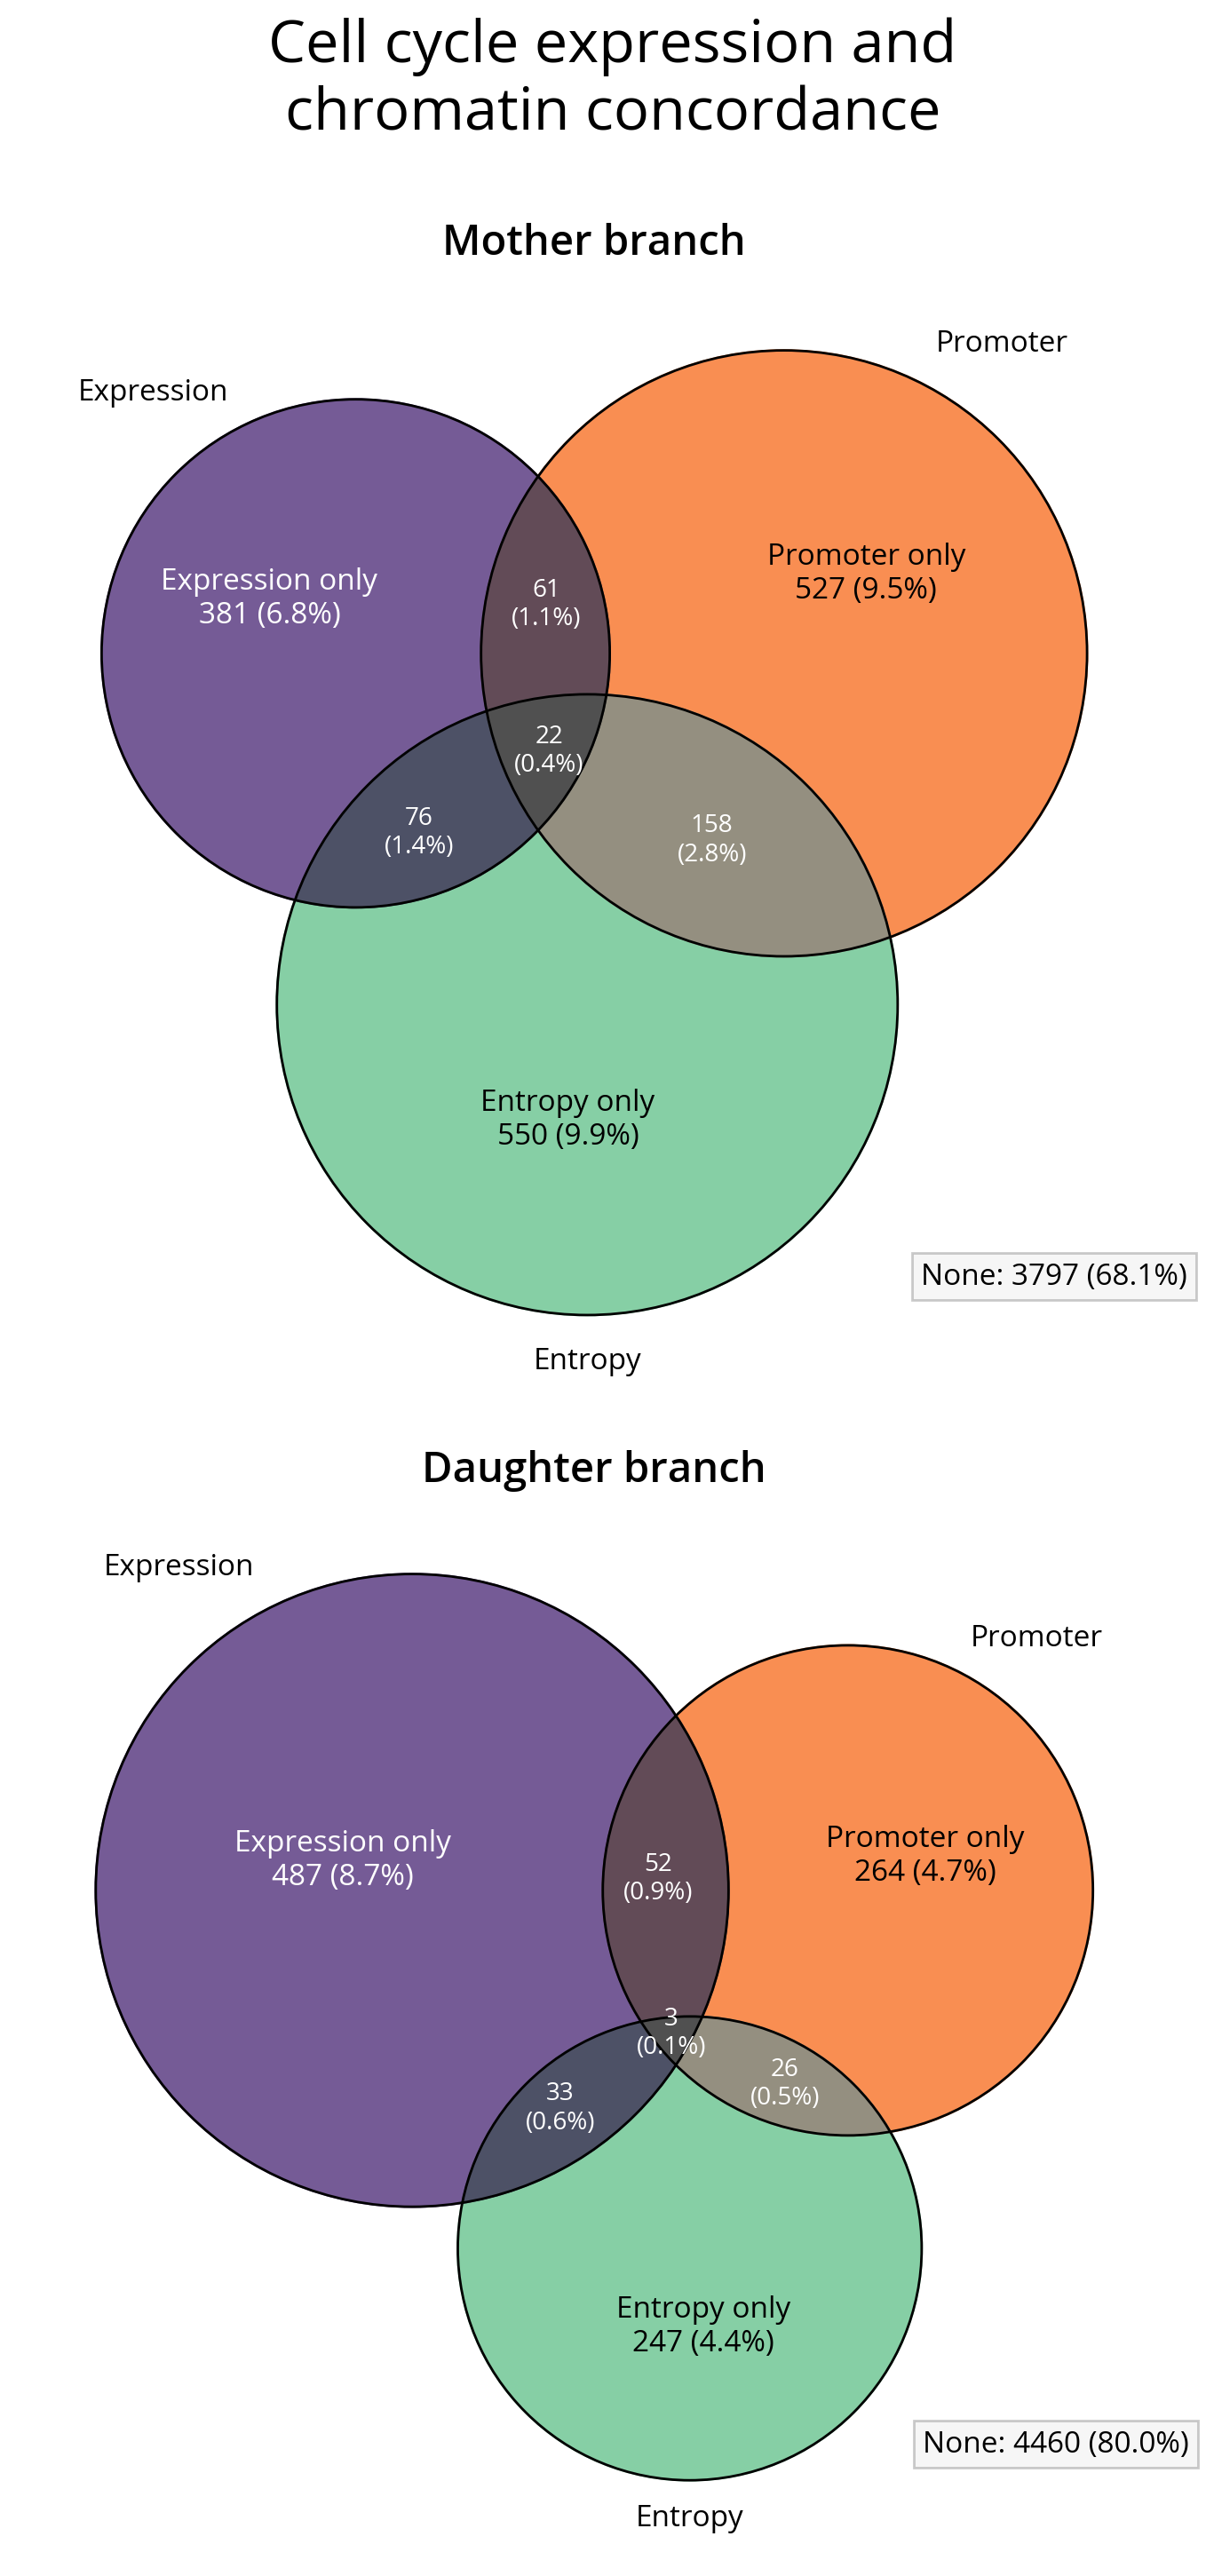

In [980]:
analyzer.plot_venn_diagrams()

In [1020]:
from pipeline.figure_composer import FigureCompositor

# Define image paths
image_names = [
    'metrics_venn3',
    'expression_polar',
    'promoters_polar',
    'entropy_polar',
    'timing_tx_chrom_mother',
    'timing_tx_chrom_mother_legend',
    'timing_tx_chrom_daughter'
]

plots_dir = 'output/prototype_pipeline_subset/expression_chromatin'
image_paths = [f"{plots_dir}/{name}.png" for name in image_names]
    
# Create compositor with a scale factor of 4
# Logical canvas size is 1024x800, but actual output will be 4096x3200
compositor = FigureCompositor(1024, 800, background_color=(255, 255, 255),
                             debug_mode=True, scale_factor=4.0)

# Place images individually
# All coordinates and dimensions are specified in logical pixels
# but will be rendered at 4x resolution
margin = 20
venn_width = 320
pad_one = 20  # Added this variable that was missing

# -------- Venn diagram -------------
compositor.place_image(image_paths[0], margin, margin, venn_width, None, 'venn3')

# Example using the new add_panel_label_to_image function
compositor.add_panel_label_to_image('venn3', 'A', offset=(5, 5), 
                                   background=(240, 240, 240), bg_padding=3)

polar_width = 330
polar_x = venn_width+pad_one+margin
img = compositor.place_image(image_paths[1], polar_x, margin, polar_width, 
                      None, 'tx_polar')
polar_height = img['logical_size'][1]  # Use logical_size instead of size

# Add label to the polar plot
compositor.add_panel_label_to_image('tx_polar', 'B', offset=(5, 5),
                                   background=(240, 240, 240))

# -------- Polar plots -------------
pad_x_polar = 30
pad_y_polar = 20

compositor.place_image(image_paths[2], polar_x, margin+polar_height+pad_y_polar, polar_width, 
                      None, 'prom_polar')
compositor.add_panel_label_to_image('prom_polar', 'C', offset=(5, 5))

compositor.place_image(image_paths[3], polar_x, margin+polar_height*2+pad_y_polar*2, polar_width,
                      None, 'entropy_polar')
compositor.add_panel_label_to_image('entropy_polar', 'D', offset=(5, 5))

# -------- Timing plots -------------
timing_width = 280
timing_x = polar_x+polar_width+pad_x_polar
img = compositor.place_image(image_paths[4], timing_x, margin, timing_width, 
                      None, 'mother_time')
timing_height = img['logical_size'][1]  # Use logical_size for logical height
compositor.add_panel_label_to_image('mother_time', 'E', offset=(5, 5))

pad_time = 20
lgd_img = compositor.place_image(image_paths[5], timing_x, margin+timing_height+pad_time, 
                      timing_width, None, 'legend_time')
lgd_height = lgd_img['logical_size'][1]  # Use logical_size for logical height

compositor.place_image(image_paths[6], timing_x, margin+timing_height+pad_time+lgd_height+\
                      pad_time, timing_width, None, 'daughter_time')
compositor.add_panel_label_to_image('daughter_time', 'F', offset=(5, 5))

# You can still use the original method for adding labels not attached to images
padding = 5
# compositor.add_panel_label("G", 50, 700)  # Example of a standalone label

# Save the figure - will be 4x the logical resolution
compositor.save("output/prototype_pipeline_subset/expression_chromatin/Figure_2.png")

Debug figure saved to: output/prototype_pipeline_subset/expression_chromatin/Figure_2_debug.png
Clean figure saved to: output/prototype_pipeline_subset/expression_chromatin/Figure_2.png


True